## Data Loading

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df = pd.read_csv("train.csv")

## Data Exploration

In [201]:
#View the Dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [202]:
#returns data types and any missing info
df.info()

#We can see that Age and Cabin fields are missing entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [203]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [204]:
#confirming that there are 891 entries in the table
len(df)

891

In [205]:
df.value_counts("Pclass")

,count
Pclass,
3,491
1,216
2,184


In [206]:
df.value_counts("Embarked")

#Embarked Column is the point of embarkation. "S" means Southampton, "Q" means Queenstown,
#"C" means Cherbourg

,count
Embarked,
S,644
C,168
Q,77


In [207]:
#Statistics about the age of the passengers
df["Age"].describe()

#We observe that there are only 714 entries for age, while there should be 891

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: xlabel='Age'>

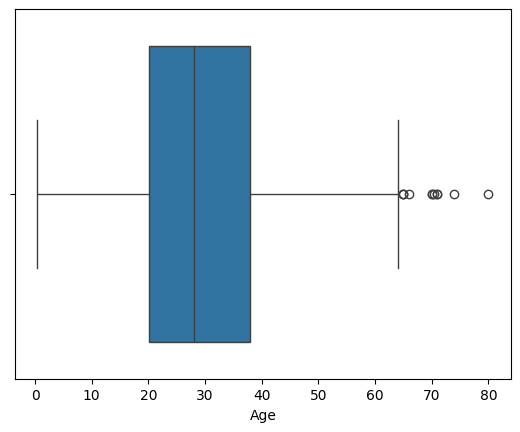

In [208]:
#Graphical representation of Titanic Passengers Age
sns.boxplot(data = df, x = "Age")

<Axes: xlabel='Pclass', ylabel='Age'>

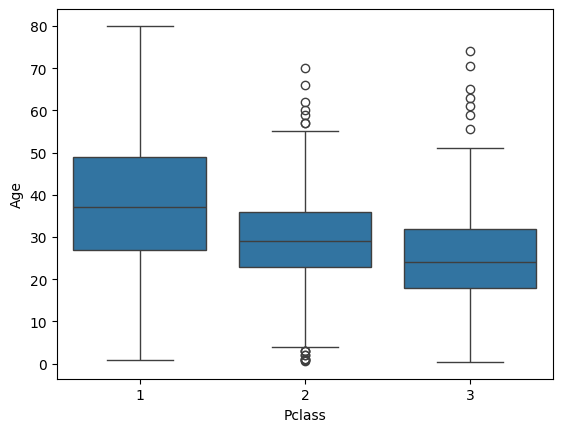

In [209]:
#Visual of Titanic Passengers Age by Class
sns.boxplot(data = df, x = "Pclass", y = "Age")

In [210]:
#Visual of Titanic Passengers Ticket Rates
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


There is an important insight for the ages of the Passengers. For the passengers in the **first** class (wealthier), there ages range from 0 to 80. Passengers in the **second** and **third** classes are poorer. You do not see many elderly people (50+) in the second or third class.

# Data Cleaning

In [211]:
#returns the number of null entries in each column
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [212]:
del df['Cabin']

In [213]:
#Cabin column is gone
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [214]:
#returns all rows in df where Age is null
df_age_null = df[df['Age'].isna()]

<Axes: xlabel='Pclass', ylabel='Age'>

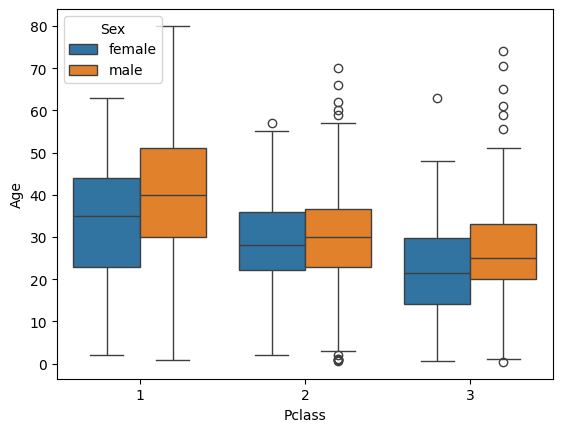

In [215]:
# Representation of Titanic Passengers Age by Class and Sex
#hue attribute creates separate boxes for males and females within each passenger
#class
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex")

In [216]:
df.groupby(['Pclass', 'Sex'])['Age'].mean()

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64

In [217]:
group_means = df.groupby(['Pclass', 'Sex'])['Age'].transform('mean')

# 2. Only fill in where Age is currently null
df.loc[df['Age'].isna(), 'Age'] = group_means

# Display the count of nulls in Age to confirm imputation
print(f"Remaining nulls: {df['Age'].isna().sum()}")

Remaining nulls: 0


In [218]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [219]:
#Removed the two data points where Embarked is null
df = df[~df['Embarked'].isna()]

In [220]:
#All null values are removed from the DataFrame
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [221]:
df.tail(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
861,862,0,2,"Giles, Mr. Frederick Edward",male,21.000000,1,0,28134,11.5000,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.000000,0,0,17466,25.9292,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,21.750000,8,2,CA. 2343,69.5500,S
864,865,0,2,"Gill, Mr. John William",male,24.000000,0,0,233866,13.0000,S
865,866,1,2,"Bystrom, Mrs. (Karolina)",female,42.000000,0,0,236852,13.0000,S
866,867,1,2,"Duran y More, Miss. Asuncion",female,27.000000,1,0,SC/PARIS 2149,13.8583,C
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.000000,0,0,PC 17590,50.4958,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,26.507589,0,0,345777,9.5000,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.000000,1,1,347742,11.1333,S
870,871,0,3,"Balkic, Mr. Cerin",male,26.000000,0,0,349248,7.8958,S


In [222]:
#To make easier charts later, change the Survived column values of 1 and 0 to
#"Survived" and "Not Survived"
df['Survived'] = df['Survived'].map({1: "Survived", 0: "Died"})

In [223]:
#change class to the appropriate class
df['Pclass'] = df['Pclass'].map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'})

In [224]:
#change the Embarked Code to the actual name
df['Embarked'] = df['Embarked'].map({'S': 'Southampton', 'Q': 'Queenstown', 'C': 'Cherbourg'})

In [225]:
#Capitalize first letter of Sex column
#capitalize() function capitalizes oonly the first letter in a string
df['Sex'] = df['Sex'].str.capitalize()

In [226]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,Died,Third Class,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,Southampton
1,2,Survived,First Class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,Cherbourg
2,3,Survived,Third Class,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton
3,4,Survived,First Class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,Southampton
4,5,Died,Third Class,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,Southampton


In [227]:
#Create a new column called Family Size, instead of having two separate columns
#for having a parent and having a sibling
df['Family Size'] = df['Parch'] + df['SibSp'] + 1

#See if the passenger is alone or with family
df['Is Alone'] = df['Family Size'].map(lambda x: "Alone" if x == 1 else "Not Alone")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family Size,Is Alone
0,1,Died,Third Class,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,Southampton,2,Not Alone
1,2,Survived,First Class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,Cherbourg,2,Not Alone
2,3,Survived,Third Class,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton,1,Alone
3,4,Survived,First Class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,Southampton,2,Not Alone
4,5,Died,Third Class,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,Southampton,1,Alone


In [228]:
df['Fare'].describe()

,Fare
count,889.000000
mean,32.096681
std,49.697504
min,0.000000
25%,7.895800
50%,14.454200
75%,31.000000
max,512.329200


<Axes: ylabel='Fare'>

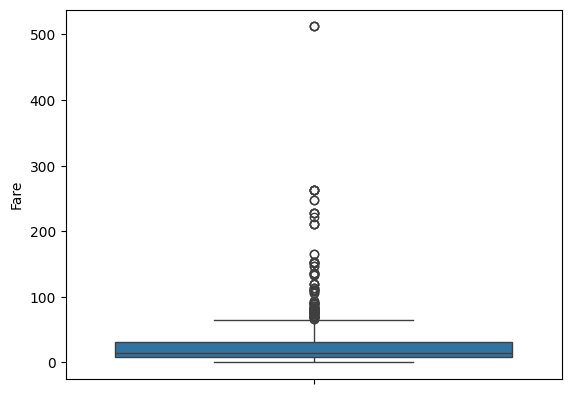

In [229]:
#As we can see, it is extremely right-skewed (many low fares, som very expensive ones)
sns.boxplot(data = df['Fare'])

In [230]:
#To make better data visualizations later, we will apply a Natural Log Transformation
#to the Fare column
df['Log_Fare'] = np.log1p(df['Fare'])

del df['Fare']

df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Embarked,Family Size,Is Alone,Log_Fare
0,1,Died,Third Class,"Braund, Mr. Owen Harris",Male,22.000000,1,0,A/5 21171,Southampton,2,Not Alone,2.110213
1,2,Survived,First Class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.000000,1,0,PC 17599,Cherbourg,2,Not Alone,4.280593
2,3,Survived,Third Class,"Heikkinen, Miss. Laina",Female,26.000000,0,0,STON/O2. 3101282,Southampton,1,Alone,2.188856
3,4,Survived,First Class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.000000,1,0,113803,Southampton,2,Not Alone,3.990834
4,5,Died,Third Class,"Allen, Mr. William Henry",Male,35.000000,0,0,373450,Southampton,1,Alone,2.202765
5,6,Died,Third Class,"Moran, Mr. James",Male,26.507589,0,0,330877,Queenstown,1,Alone,2.246893
6,7,Died,First Class,"McCarthy, Mr. Timothy J",Male,54.000000,0,0,17463,Southampton,1,Alone,3.967694
7,8,Died,Third Class,"Palsson, Master. Gosta Leonard",Male,2.000000,3,1,349909,Southampton,5,Not Alone,3.094446
8,9,Survived,Third Class,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Female,27.000000,0,2,347742,Southampton,3,Not Alone,2.495954
9,10,Survived,Second Class,"Nasser, Mrs. Nicholas (Adele Achem)",Female,14.000000,1,0,237736,Cherbourg,2,Not Alone,3.436268


In [231]:
#Married Woman are referred using their Husband's name, let's refer to them using their own name
def clean_married_women_names(name):
    if '(' in name and ')' in name and 'Mrs.' in name:
        last_name = name.split(',')[0].strip()

        actual_name = name.split('(')[1].split(')')[0].strip()

        return f"{last_name}, Mrs. {actual_name}"

    return name

df['Name'] = df['Name'].apply(clean_married_women_names)

# View the result
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Embarked,Family Size,Is Alone,Log_Fare
0,1,Died,Third Class,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,Southampton,2,Not Alone,2.110213
1,2,Survived,First Class,"Cumings, Mrs. Florence Briggs Thayer",Female,38.0,1,0,PC 17599,Cherbourg,2,Not Alone,4.280593
2,3,Survived,Third Class,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,Southampton,1,Alone,2.188856
3,4,Survived,First Class,"Futrelle, Mrs. Lily May Peel",Female,35.0,1,0,113803,Southampton,2,Not Alone,3.990834
4,5,Died,Third Class,"Allen, Mr. William Henry",Male,35.0,0,0,373450,Southampton,1,Alone,2.202765


In [232]:
del df['Parch']
del df['SibSp']

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Embarked,Family Size,Is Alone,Log_Fare
0,1,Died,Third Class,"Braund, Mr. Owen Harris",Male,22.0,A/5 21171,Southampton,2,Not Alone,2.110213
1,2,Survived,First Class,"Cumings, Mrs. Florence Briggs Thayer",Female,38.0,PC 17599,Cherbourg,2,Not Alone,4.280593
2,3,Survived,Third Class,"Heikkinen, Miss. Laina",Female,26.0,STON/O2. 3101282,Southampton,1,Alone,2.188856
3,4,Survived,First Class,"Futrelle, Mrs. Lily May Peel",Female,35.0,113803,Southampton,2,Not Alone,3.990834
4,5,Died,Third Class,"Allen, Mr. William Henry",Male,35.0,373450,Southampton,1,Alone,2.202765


In [236]:
#Change index of the DataFrame to PassengerId
df = df.set_index('PassengerId')

In [244]:
df.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Embarked,Family Size,Is Alone,Log_Fare
PassengerId,,,,,,,,,,
1,Died,Third Class,"Braund, Mr. Owen Harris",Male,22.0,A/5 21171,Southampton,2,Not Alone,2.110213
2,Survived,First Class,"Cumings, Mrs. Florence Briggs Thayer",Female,38.0,PC 17599,Cherbourg,2,Not Alone,4.280593
3,Survived,Third Class,"Heikkinen, Miss. Laina",Female,26.0,STON/O2. 3101282,Southampton,1,Alone,2.188856
4,Survived,First Class,"Futrelle, Mrs. Lily May Peel",Female,35.0,113803,Southampton,2,Not Alone,3.990834
5,Died,Third Class,"Allen, Mr. William Henry",Male,35.0,373450,Southampton,1,Alone,2.202765


## Data Visualization

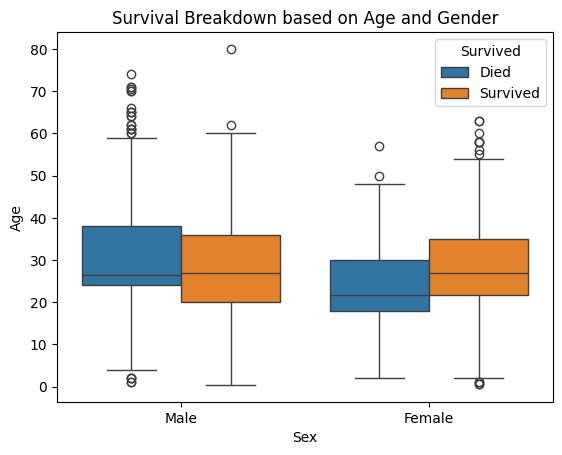

In [237]:
#Age Distribution of Survivors based on Sex

sns.boxplot(data = df, x = "Sex", y = "Age", hue = "Survived")
plt.title("Survival Breakdown based on Age and Gender")
plt.show()

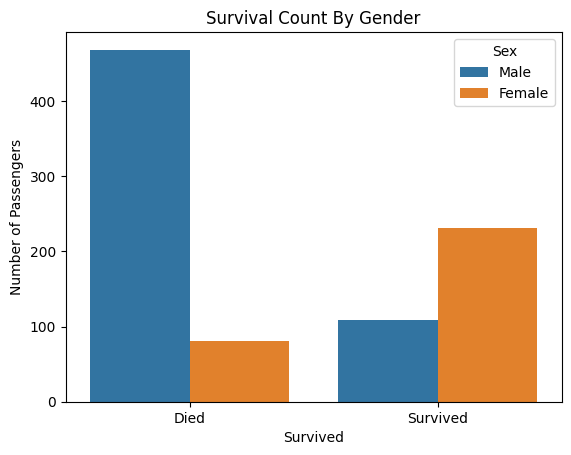

In [246]:
#Survival Count of Survival based on Gender
sns.countplot(data = df, x = "Survived", hue = "Sex")
plt.title("Survival Count By Gender")
plt.ylabel("Number of Passengers")
plt.show()

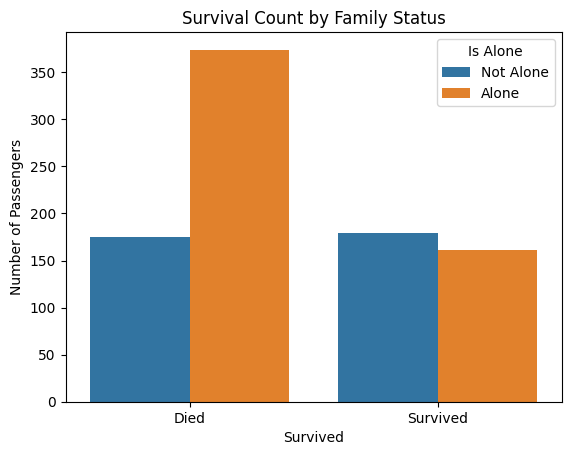

In [247]:
sns.countplot(data = df, x = "Survived", hue = "Is Alone")
plt.title("Survival Count by Family Status")
plt.ylabel("Number of Passengers")
plt.show()

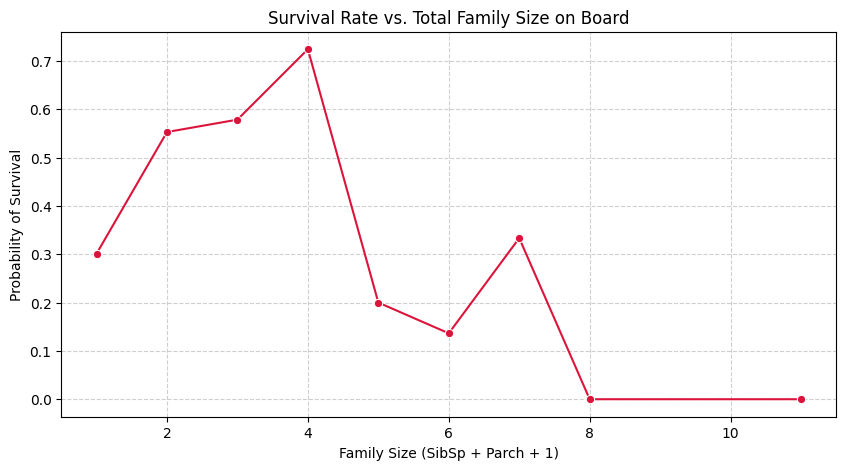

In [252]:
#Family Size Dynamics
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Family Size', y=df['Survived'].map({'Survived':1, 'Died':0}),
             marker='o', color='crimson', errorbar=None)

plt.title('Survival Rate vs. Total Family Size on Board')
plt.xlabel('Family Size (SibSp + Parch + 1)')
plt.ylabel('Probability of Survival')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

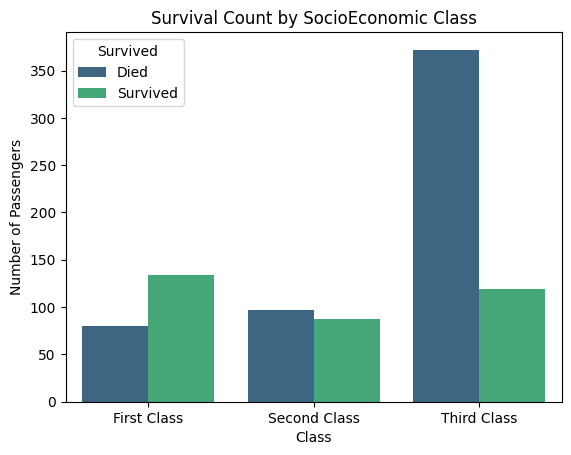

In [250]:
# SocioEconomic Class Disparity
sns.countplot(data = df, x = "Pclass", hue = "Survived", palette = 'viridis', order=['First Class', 'Second Class', 'Third Class'])
plt.title("Survival Count by SocioEconomic Class")
plt.xlabel("Class")
plt.ylabel("Number of Passengers")
plt.show()